In [1]:
import cv2
from PIL import Image
import numpy as np

class CLAHETransform:
    def __init__(self, clip_limit=2.0, tile_grid_size=(8,8)):
        self.clahe = cv2.createCLAHE(
            clipLimit=clip_limit,
            tileGridSize=tile_grid_size
        )

    def __call__(self, img):
        img = np.array(img)

        # Convert to LAB color space
        lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)

        # Apply CLAHE on L channel
        l = self.clahe.apply(l)

        # Merge back
        lab = cv2.merge((l, a, b))
        img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

        return Image.fromarray(img)

In [6]:
import matplotlib.pyplot as plt

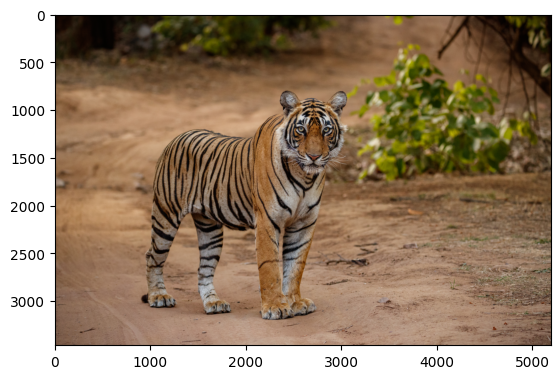

In [7]:
img = Image.open("image.jpg")
plt.imshow(img)

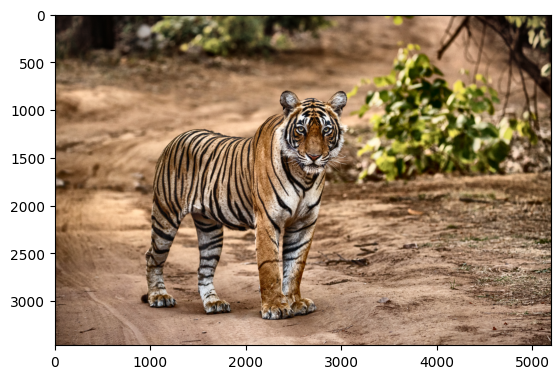

In [8]:

clahe = CLAHETransform()
clahed = clahe(img)
plt.imshow(clahed)